In [1]:
import pandas as pd 
df = pd.read_csv("../data/fraudTrain.csv")
df.shape

(1296675, 23)

In [2]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [4]:
df = df.drop(columns=['Unnamed: 0'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[us]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  str           
 3   category               1296675 non-null  str           
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  str           
 6   last                   1296675 non-null  str           
 7   gender                 1296675 non-null  str           
 8   street                 1296675 non-null  str           
 9   city                   1296675 non-null  str           
 10  state                  1296675 non-null  str           
 11  zip                    1296675 non-null  int64         
 12  lat                    1296675 non-null

In [5]:
df['is_fraud'].value_counts()
df['is_fraud'].value_counts(normalize=True)*100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

In [6]:
df.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


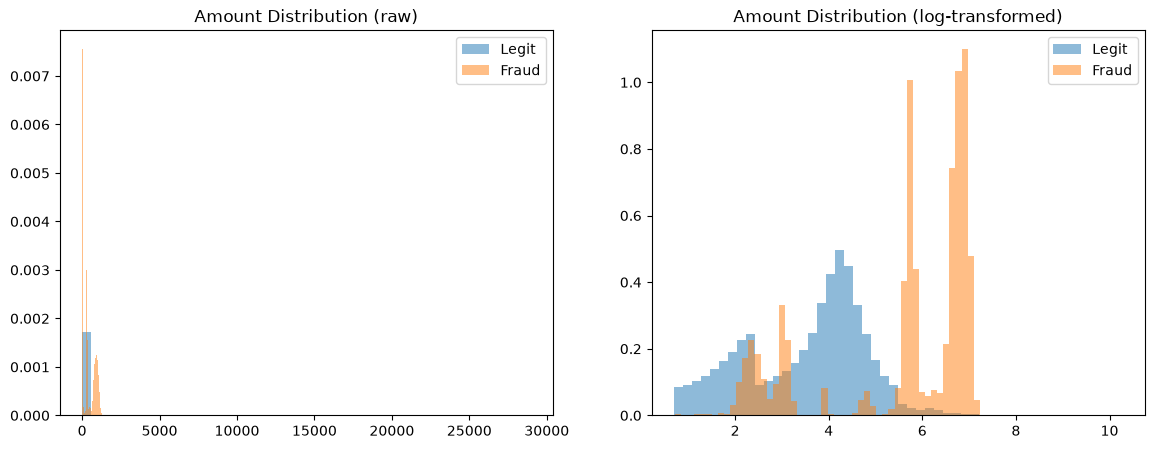

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scale
axes[0].hist(df[df['is_fraud']==0]['amt'], bins=50, alpha=0.5, label='Legit', density=True)
axes[0].hist(df[df['is_fraud']==1]['amt'], bins=50, alpha=0.5, label='Fraud', density=True)
axes[0].set_title('Amount Distribution (raw)')
axes[0].legend()

# Log scale — because of the skew we just found
axes[1].hist(np.log1p(df[df['is_fraud']==0]['amt']), bins=50, alpha=0.5, label='Legit', density=True)
axes[1].hist(np.log1p(df[df['is_fraud']==1]['amt']), bins=50, alpha=0.5, label='Fraud', density=True)
axes[1].set_title('Amount Distribution (log-transformed)')
axes[1].legend()

plt.show()

In [8]:
category_fraud = df.groupby('category')['is_fraud'].agg(['count', 'sum', 'mean'])
category_fraud.columns = ['total_transactions', 'fraud_count', 'fraud_rate']
category_fraud['fraud_rate_pct'] = category_fraud['fraud_rate'] * 100
category_fraud = category_fraud.sort_values('fraud_rate_pct', ascending=False)
print(category_fraud)

                total_transactions  fraud_count  fraud_rate  fraud_rate_pct
category                                                                   
shopping_net                 97543         1713    0.017561        1.756149
misc_net                     63287          915    0.014458        1.445795
grocery_pos                 123638         1743    0.014098        1.409761
shopping_pos                116672          843    0.007225        0.722538
gas_transport               131659          618    0.004694        0.469394
misc_pos                     79655          250    0.003139        0.313853
grocery_net                  45452          134    0.002948        0.294817
travel                       40507          116    0.002864        0.286370
entertainment                94014          233    0.002478        0.247835
personal_care                90758          220    0.002424        0.242403
kids_pets                   113035          239    0.002114        0.211439
food_dining 

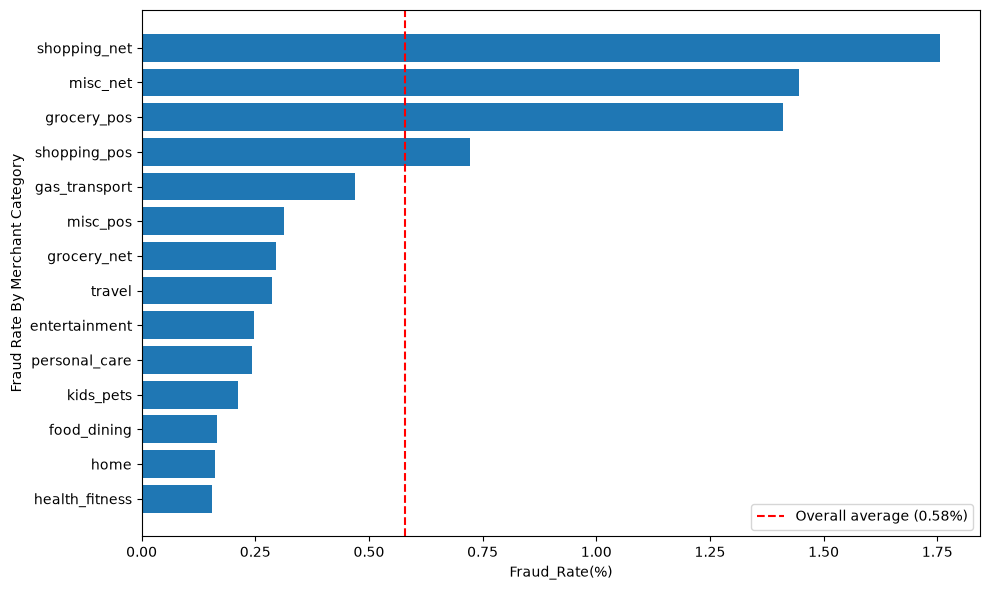

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(category_fraud.index,category_fraud['fraud_rate_pct'])
plt.axvline(x=0.5788, color='red', linestyle='--', label='Overall average (0.58%)')
plt.xlabel('Fraud_Rate(%)')
plt.ylabel('Fraud Rate By Merchant Category')
plt.legend()
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [10]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek  # 0=Monday, 6=Sunday

hourly_fraud = df.groupby('hour')['is_fraud'].agg(['count', 'sum', 'mean'])
hourly_fraud.columns = ['total_transactions', 'fraud_count', 'fraud_rate']
hourly_fraud['fraud_rate_pct'] = hourly_fraud['fraud_rate'] * 100
print(hourly_fraud)

      total_transactions  fraud_count  fraud_rate  fraud_rate_pct
hour                                                             
0                  42502          635    0.014940        1.494047
1                  42869          658    0.015349        1.534909
2                  42656          625    0.014652        1.465210
3                  42769          609    0.014239        1.423929
4                  41863           46    0.001099        0.109882
5                  42171           60    0.001423        0.142278
6                  42300           40    0.000946        0.094563
7                  42203           56    0.001327        0.132692
8                  42505           49    0.001153        0.115281
9                  42185           47    0.001114        0.111414
10                 42271           40    0.000946        0.094628
11                 42082           42    0.000998        0.099805
12                 65257           67    0.001027        0.102671
13        

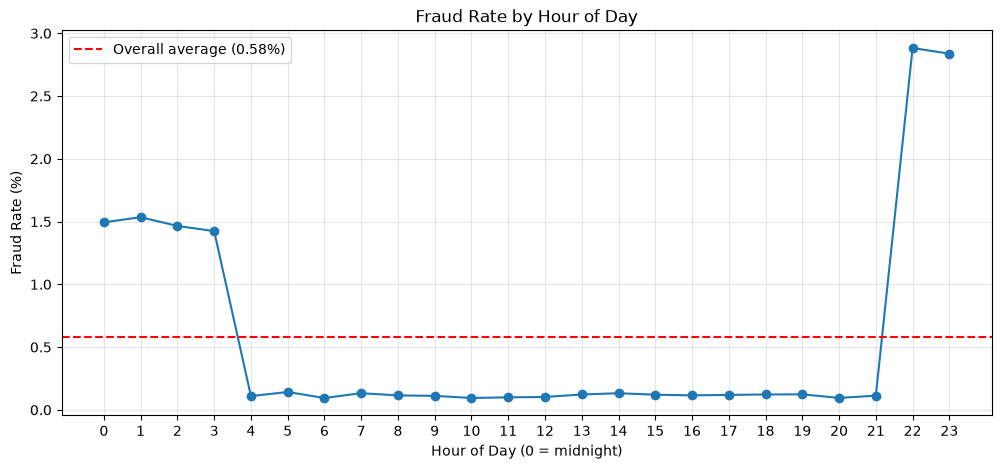

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_fraud.index, hourly_fraud['fraud_rate_pct'], marker='o')
plt.axhline(y=0.5788, color='red', linestyle='--', label='Overall average (0.58%)')
plt.xlabel('Hour of Day (0 = midnight)')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
daily_fraud = df.groupby('day_of_week')['is_fraud'].agg(['count', 'sum', 'mean'])
daily_fraud.columns = ['total_transactions', 'fraud_count', 'fraud_rate']
daily_fraud['fraud_rate_pct'] = daily_fraud['fraud_rate'] * 100
print(daily_fraud)

             total_transactions  fraud_count  fraud_rate  fraud_rate_pct
day_of_week                                                             
0                        254282         1182    0.004648        0.464838
1                        160227          935    0.005835        0.583547
2                        131073          859    0.006554        0.655360
3                        147285         1008    0.006844        0.684387
4                        152272         1079    0.007086        0.708600
5                        200957         1227    0.006106        0.610578
6                        250579         1216    0.004853        0.485276


In [13]:
from math import radians, sin, cos, sqrt, atan2
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['distance_km'] = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

df.groupby('is_fraud')['distance_km'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,76.113756,29.119051,0.022255,55.332701,78.233012,98.504498,152.117173
1,7506.0,76.268330,28.752602,0.738769,55.632890,77.931954,98.391090,144.522410


In [14]:
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

df.groupby('is_fraud')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,45.511960,17.398818,13.0,32.0,43.0,57.0,95.0
1,7506.0,48.321609,18.864543,14.0,33.0,47.0,60.0,93.0


In [15]:
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_fraud = df.groupby('age_group', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
age_fraud.columns = ['total_transactions', 'fraud_count', 'fraud_rate']
age_fraud['fraud_rate_pct'] = age_fraud['fraud_rate'] * 100
print(age_fraud)

           total_transactions  fraud_count  fraud_rate  fraud_rate_pct
age_group                                                             
18-25                  144604          895    0.006189        0.618932
26-35                  299697         1417    0.004728        0.472811
36-45                  266603         1146    0.004299        0.429853
46-55                  242995         1426    0.005868        0.586843
56-65                  163684         1244    0.007600        0.760001
65+                    179092         1378    0.007694        0.769437


In [16]:
print("Negative amounts:", (df['amt'] < 0).sum())
print("Zero amounts:", (df['amt'] == 0).sum())
print("Negative or impossible ages:", ((df['age'] < 0) | (df['age'] > 100)).sum())
print("Duplicate transaction IDs:", df['trans_num'].duplicated().sum())

Negative amounts: 0
Zero amounts: 0
Negative or impossible ages: 0
Duplicate transaction IDs: 0


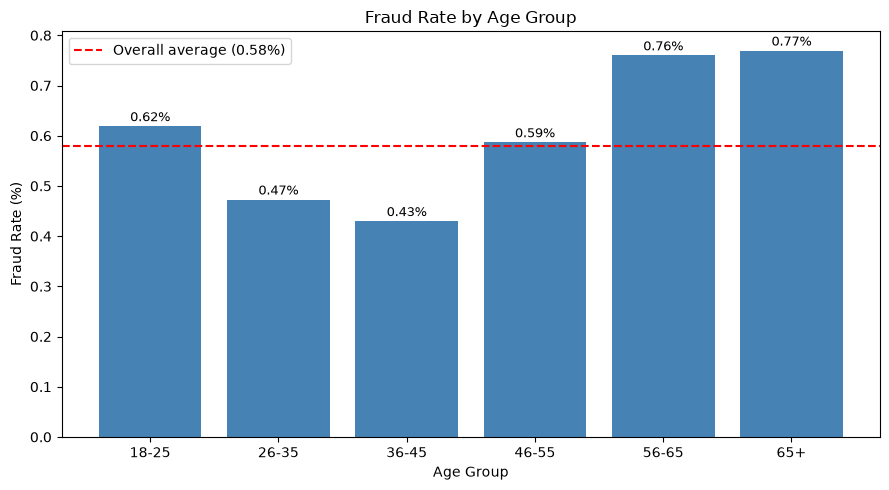

In [17]:
plt.figure(figsize=(9, 5))
bars = plt.bar(age_fraud.index, age_fraud['fraud_rate_pct'], color='steelblue')
plt.axhline(y=0.5788, color='red', linestyle='--', label='Overall average (0.58%)')
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Age Group')
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.2f}%',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [18]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,distance_km,age,age_group
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,78.597568,30,26-35
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,30.212176,40,36-45
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,108.206083,56,56-65
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,95.673231,52,46-55
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,77.556744,32,26-35
